# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

In [3]:
df_names_list = [
    'gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 
    'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 
    'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'
    ]
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite'

In [4]:
dict_of_gdfs = {}
for i in df_names_list:
        gdf = import_spatial_point_data_frame(
                connection_link_lnx = repo_path_unix+"/03_simulated_data/simulated_data.sqlite",
                layer_name =i,
                crs_param = 3857
                                        )
        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  f'{i}_sp'
                                        )
        df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
        gdf2 = gdf.merge(df2, on = ['unit_id'])
        dict_of_gdfs[i] = gdf2

In [5]:
gdf_pre =dict_of_gdfs['gdf_rho_0_75'].copy()
gdf = gdf_pre.drop(columns = [c for c in dict_of_gdfs['gdf_rho_0_75'].columns.tolist() if 'spatial_predictor' in c]).copy()
df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  'gdf_rho_0_75_sp_t_dr5'
                                        )

df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
gdf2 = gdf.merge(df2, on = ['unit_id'])

In [6]:
dict_of_gdfs['gdf_rho_0_75'].isna().any().any()

np.False_

In [7]:
dict_of_gdfs.keys()

dict_keys(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

# Modelling causal inference

## Single df

### Data preparation

In [17]:
X_ns = gdf2[["c1","c2",
         ]].values
X = gdf2[["c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]].values
y = gdf2["y"].values.reshape(-1,1)
T = gdf2["t"].values
T_tot = gdf2["t_tot"].values
Xdf = gdf2[['t','odr_1','odr_2','odr_3',
            #'odr_4', 
            "c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]]
Xdf2 = gdf2[['t','odr_1','odr_2','odr_3',
             #'odr_4', 
             "c1","c2",
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf2["y_ns"]
Y = gdf2['y'].values


gdf3 = gdf2.copy()
gdf3['t_tot_cat3'] = gdf3['t_tot_cat']
gdf3.loc[gdf3['t_tot_cat']=='treated_outer_ring4', 't_tot_cat3'] = 'control'

T_M= gdf3['t_tot_cat3'].values
T_M= T_M.astype(str)

gdf3 = gdf3.rename(columns = {'t': 'treated_inner_ring',
                              'odr_1':'treated_outer_ring1', 
                              'odr_2':'treated_outer_ring2', 
                              'odr_3':'treated_outer_ring3', 
                              'odr_4':'treated_outer_ring4'
                              })
T_mult = gdf3[[ 
         'treated_inner_ring', 'treated_outer_ring1','treated_outer_ring2','treated_outer_ring3',
         #'treated_outer_ring4'
         ]].to_numpy()

gdf2_22 = gdf.copy()
gdf2_22["x"] = gdf2_22.geometry.x.astype(int)
gdf2_22["y"] = gdf2_22.geometry.y.astype(int)

n = len(gdf2_22)

coords = np.array(
        list(zip(gdf2_22["x"], gdf2_22["y"]))
    )


W_mat = DistanceBand(
        coords,
        threshold=100 + 1,
        binary=True,
        silence_warnings=True
    ) 

In [38]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                            #4:'treated_outer_ring4'
                                             }

replacing_dict_odr_ring = {'t':'treated_inner_ring', 
                                                                        'odr_1':'treated_outer_ring1', 
                                                                        'odr_2':'treated_outer_ring2',
                                                                        'odr_3':'treated_outer_ring3',
                                                                          #'odr_4':'treated_outer_ring4'
                                                                          }

### Multi treatment

#### With spatial regressors

##### S learner

In [35]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT, lb_slearn_multT, ub_slearn_multT = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite_slearn_multT = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df_slearn_multT = pd.DataFrame(ite_slearn_multT).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_multT['treated'] = T_M
ITE_df_slearn_multT['ITE_real'] = gdf2['tau']
ITE_df_slearn_multT['Y'] = Y
ITE_df_slearn_multT

,treated_inner_ring,treated_outer_ring1,treated_outer_ring2,treated_outer_ring3,treated,ITE_real,Y
0,0.222360,0.384104,0.008172,0.004287,control,0.0,3.583302
1,1.466920,1.092709,0.062885,0.004194,control,0.0,1.664774
2,1.545003,0.558422,0.067997,-0.002160,control,0.0,0.924681
3,2.918534,1.889261,0.127504,0.020668,control,0.0,-1.424234
4,2.253641,1.110219,0.170300,0.041785,control,0.0,0.939380
...,...,...,...,...,...,...,...
795,1.333539,0.214520,0.005981,0.000805,control,0.0,0.515627
796,2.148403,1.449596,0.033977,0.016667,control,0.0,-0.243606
797,2.372510,0.051316,-0.011038,0.007522,control,0.0,-0.990687
798,1.525693,1.140704,0.100166,0.021084,control,0.0,0.898532


In [21]:
df_effectbase = pd.DataFrame({
                'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2','treated_outer_ring3',
                        #'treated_outer_ring4'
                        ],
              'true_effect':[gdf2[gdf2['t'] == 1]['tau'].mean(), gdf2[gdf2['odr_1'] == 1]['tau'].mean(), 
                             gdf2[gdf2['odr_2'] == 1]['tau'].mean(), gdf2[gdf2['odr_3'] == 1]['tau'].mean(), 
                               #gdf2[gdf2['odr_4'] == 1]['tau'].mean()
                               ],
              })
df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_slearn_multT,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_sp', treated_col='treated')
df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')
df_multi_effect_pre1

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp
0,treated_inner_ring,1.500000,1.554898,0.072790
1,treated_outer_ring1,1.049929,0.756394,0.074071
2,treated_outer_ring2,0.535380,0.040590,0.009621
3,treated_outer_ring3,0.123083,0.012758,0.002603


##### Linear DML

In [36]:
est_LDML = LinearDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)

est_LDML.fit(Y, T_mult, X=X, 
        #W=W
        )
te_pred_LDML = est_LDML.const_marginal_effect(X)

ITE_LDML= pd.DataFrame(te_pred_LDML).rename(columns = replacing_dict_0_ring)
ITE_LDML['treated'] = T_M
df_multi_treatment_effects_LDML = make_treatment_effects_df(ITE_LDML,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mLDML_sp', treated_col='treated')
df_multi_effect_pre2 = df_multi_effect_pre1.merge(df_multi_treatment_effects_LDML, on = 'ring', how= 'left')
df_multi_effect_pre2 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648


##### Causal forest

In [37]:
est2 = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

te_pred2 = est2.const_marginal_effect(X)
ITE_CF=pd.DataFrame(te_pred2).rename(columns = replacing_dict_0_ring)
ITE_CF['treated'] = T_M
df_multi_treatment_effects_CF = make_treatment_effects_df(ITE_CF,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_sp', treated_col='treated')
df_multi_effect_pre3 = df_multi_effect_pre2.merge(df_multi_treatment_effects_CF, on = 'ring', how= 'left')
df_multi_effect_pre3 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112


##### Cross sectional DiD with spatial predictors

In [39]:
model_cs_did_sp_pred = sm.OLS(y_l, X_l)
results_cs_did_sp_pred = model_cs_did_sp_pred.fit()

coef_df_cs_did_sp_pred = pd.DataFrame({
    "ring": results_cs_did_sp_pred.params.index,
    "att_mDiD_sp_pred": results_cs_did_sp_pred.params.values,
    "se_mDiD_sp_pred": results_cs_did_sp_pred.bse.values
})
coef_df_cs_did_sp_pred = coef_df_cs_did_sp_pred[coef_df_cs_did_sp_pred['ring'].isin(['t', 
                                                            'odr_1', 'odr_2',
                                                            'odr_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did_sp_pred['ring'] = coef_df_cs_did_sp_pred['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_pre4 = df_multi_effect_pre3.merge(coef_df_cs_did_sp_pred, on = 'ring', how= 'left')
df_multi_effect_pre4

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530,1.294492,0.130124
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616,0.994052,0.157574
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016,0.237278,0.148948
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112,0.178040,0.136176


##### SDM DiD

In [42]:
did_sdm_ysp = ML_Lag(
    y,
    X_l2,
    w=W_mat,              
    slx_lags=0,       
    name_y="y",
    # name_x=['t','odr_1','odr_2','odr_3','odr_4', "c1","c2"
    #         ]
)

did_sdm_ysp_coefs = did_sdm_ysp.betas.flatten()
did_sdm_ysp_ses = np.sqrt(np.diag(did_sdm_ysp.vm))
did_sdm_ysp_variables = did_sdm_ysp.name_x.copy()

coef_did_sdm_ysp = pd.DataFrame({
    "ring": did_sdm_ysp_variables,
    "att_sdm": did_sdm_ysp_coefs,
    "att_sdm_se": did_sdm_ysp_ses 
})
coef_did_sdm_ysp = coef_did_sdm_ysp[coef_did_sdm_ysp['ring'].isin(['t', 'odr_1', 'odr_2', 'odr_3'])]
coef_did_sdm_ysp['ring'] = coef_did_sdm_ysp['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_pre5 = df_multi_effect_pre4.merge(coef_did_sdm_ysp, on = 'ring', how= 'left')
df_multi_effect_pre5

ML_Lag


,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530,1.294492,0.130124,1.400015,0.115569
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616,0.994052,0.157574,1.053377,0.145766
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016,0.237278,0.148948,0.275588,0.135243
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112,0.178040,0.136176,0.210737,0.124276


#### Without spatial regressors

##### S learner

In [43]:
RF_s_learner_nsp = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT_nsp, lb_slearn_multT_nsp, ub_slearn_multT_nsp = RF_s_learner.estimate_ate(X_ns, T_M, Y, return_ci = True)
ite_slearn_multT_nsp = RF_s_learner_nsp.fit_predict(X_ns, T_M, Y)
ITE_df_slearn_multT_nsp = pd.DataFrame(ite_slearn_multT_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_df_slearn_multT_nsp['treated'] = T_M
df_multi_treatment_effects_Slearn_nsp = make_treatment_effects_df(ITE_df_slearn_multT_nsp,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_nsp', treated_col='treated')
df_multi_effect_pre6 = df_multi_effect_pre5.merge(df_multi_treatment_effects_Slearn_nsp, on = 'ring', how= 'left')
df_multi_effect_pre6

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se,att_mSlearn_nsp,se_mSlearn_nsp
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530,1.294492,0.130124,1.400015,0.115569,1.678903,0.079561
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616,0.994052,0.157574,1.053377,0.145766,1.036443,0.096466
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016,0.237278,0.148948,0.275588,0.135243,0.160635,0.031481
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112,0.178040,0.136176,0.210737,0.124276,0.036636,0.019207


##### Linear DML

In [45]:
est_LDML_nsp = LinearDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)

est_LDML_nsp.fit(Y, T_mult, X=X_ns, 
        #W=W
        )
te_pred_LDML_nsp = est_LDML_nsp.const_marginal_effect(X_ns)

ITE_LDML_nsp= pd.DataFrame(te_pred_LDML_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_LDML_nsp['treated'] = T_M
df_multi_treatment_effects_LDML_nsp = make_treatment_effects_df(ITE_LDML_nsp,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mLDML_nsp', treated_col='treated')
df_multi_effect_pre7 = df_multi_effect_pre6.merge(df_multi_treatment_effects_LDML_nsp, on = 'ring', how= 'left')
df_multi_effect_pre7 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530,1.294492,0.130124,1.400015,0.115569,1.678903,0.079561,1.625230,0.044898
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616,0.994052,0.157574,1.053377,0.145766,1.036443,0.096466,1.143691,0.096133
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016,0.237278,0.148948,0.275588,0.135243,0.160635,0.031481,0.416438,0.074090
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112,0.178040,0.136176,0.210737,0.124276,0.036636,0.019207,0.229039,0.039054


##### Causal forest

In [46]:
est2_cf_nsp = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp.tune(Y, T_mult, X=X_ns, 
          #W=W
          )
est2_cf_nsp.fit(Y, T_mult, X=X_ns, 
         #W=W
         )

te_pred2_nsp = est2_cf_nsp.const_marginal_effect(X_ns)
ITE_CF_nsp=pd.DataFrame(te_pred2_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_CF_nsp['treated'] = T_M
df_multi_treatment_effects_CF_nsp = make_treatment_effects_df(ITE_CF_nsp,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_nsp', treated_col='treated')
df_multi_effect_pre8 = df_multi_effect_pre7.merge(df_multi_treatment_effects_CF_nsp, on = 'ring', how= 'left')
df_multi_effect_pre8

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp,att_mCF_nsp,se_mCF_nsp
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530,1.294492,0.130124,1.400015,0.115569,1.678903,0.079561,1.625230,0.044898,1.645698,0.024516
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616,0.994052,0.157574,1.053377,0.145766,1.036443,0.096466,1.143691,0.096133,1.154419,0.029404
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016,0.237278,0.148948,0.275588,0.135243,0.160635,0.031481,0.416438,0.074090,0.437860,0.041313
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112,0.178040,0.136176,0.210737,0.124276,0.036636,0.019207,0.229039,0.039054,0.234080,0.015668


##### DiD without spatial predictors

In [60]:
model_cs_did = sm.OLS(y_l, X_l2)
results_cs_did = model_cs_did.fit()

coef_df_cs_did = pd.DataFrame({
    "ring": results_cs_did.params.index,
    "att_mDiD": results_cs_did.params.values,
    "se_mDiD": results_cs_did.bse.values
})
coef_df_cs_did = coef_df_cs_did[coef_df_cs_did['ring'].isin(['t', 
                                                            'odr_1', 'odr_2',
                                                            'odr_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did['ring'] = coef_df_cs_did['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_final = df_multi_effect_pre8.merge(coef_df_cs_did, on = 'ring', how= 'left')
df_multi_effect_final

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp,att_mCF_nsp,se_mCF_nsp,att_mDiD,se_mDiD
0,treated_inner_ring,1.500000,1.554898,0.072790,4.942185,0.948657,1.045451,0.023530,1.294492,0.130124,1.400015,0.115569,1.678903,0.079561,1.625230,0.044898,1.645698,0.024516,1.394253,0.094544
1,treated_outer_ring1,1.049929,0.756394,0.074071,2.231607,0.436021,0.879271,0.023616,0.994052,0.157574,1.053377,0.145766,1.036443,0.096466,1.143691,0.096133,1.154419,0.029404,1.063688,0.139080
2,treated_outer_ring2,0.535380,0.040590,0.009621,0.150014,0.275693,0.060622,0.040016,0.237278,0.148948,0.275588,0.135243,0.160635,0.031481,0.416438,0.074090,0.437860,0.041313,0.287851,0.133734
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.276832,0.183648,0.000713,0.024112,0.178040,0.136176,0.210737,0.124276,0.036636,0.019207,0.229039,0.039054,0.234080,0.015668,0.205953,0.124498


#### Results visualization

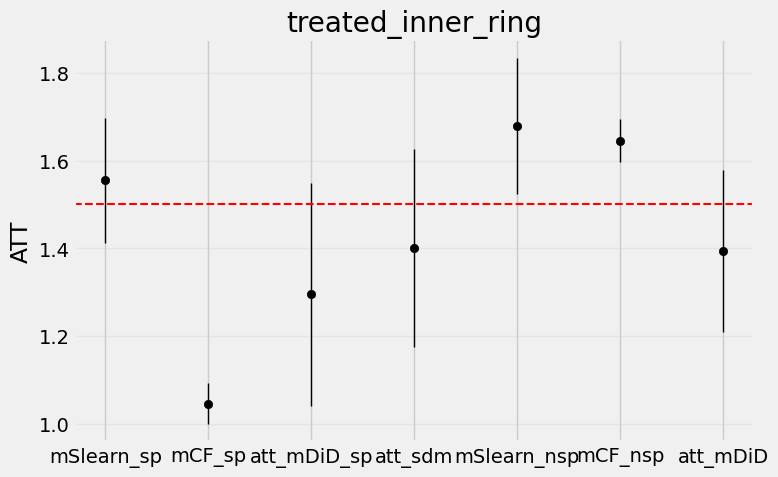

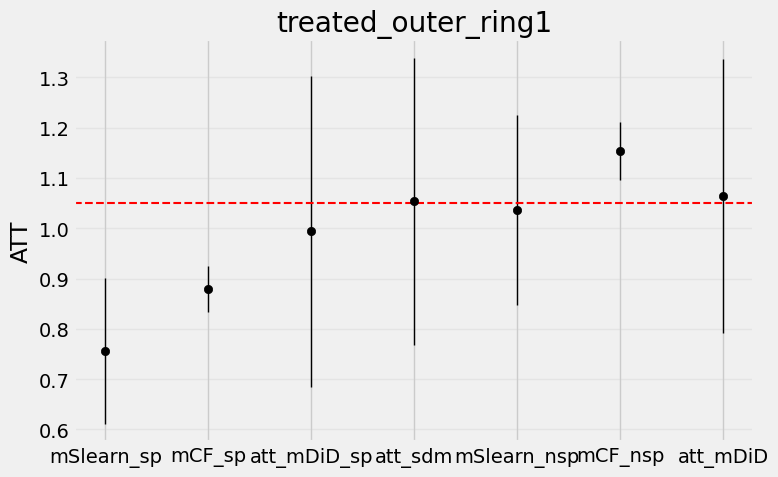

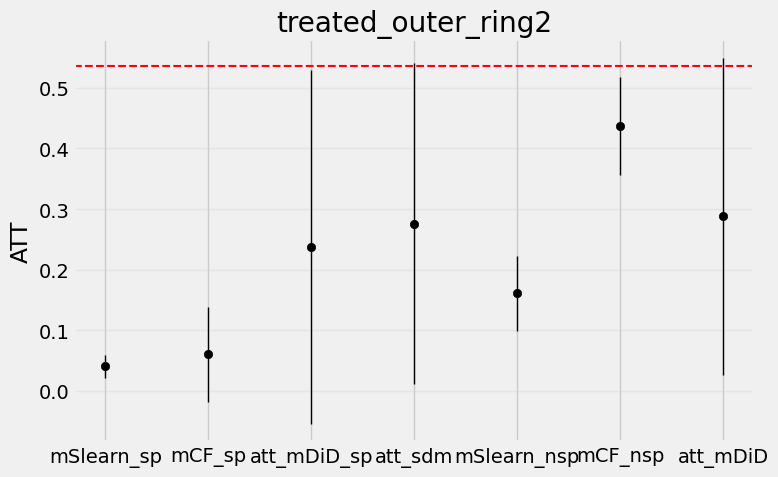

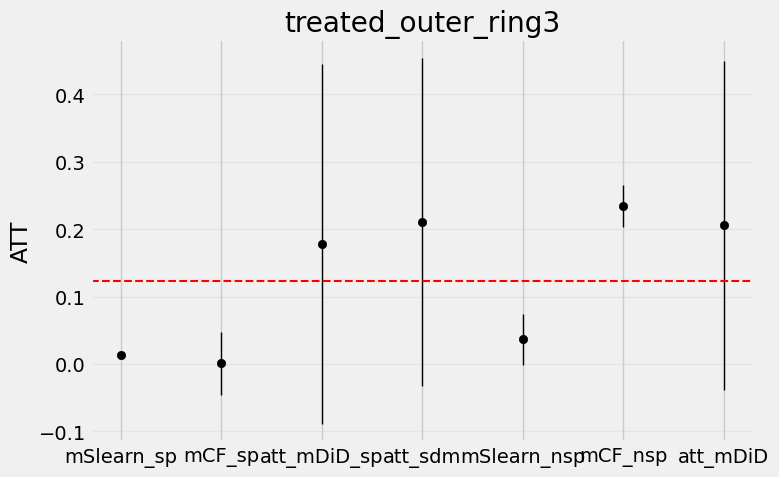

In [61]:
att_models = {
    "mSlearn_sp": ("att_mSlearn_sp", "se_mSlearn_sp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "mCF_sp": ("att_mCF_sp", "se_mCF_sp"),
    "att_mDiD_sp": ("att_mDiD_sp_pred", "se_mDiD_sp_pred"),
    "att_sdm": ("att_sdm", "att_sdm_se"),
    "mSlearn_nsp": ("att_mSlearn_nsp", "se_mSlearn_nsp"),
    #"mLDML_nsp": ("att_mLDML_nsp", "se_mLDML_nsp"),
    "mCF_nsp": ("att_mCF_nsp", "se_mCF_nsp"),
    "att_mDiD": ("att_mDiD", "se_mDiD")
}
for ring in df_multi_effect_final['ring'].unique().tolist():
    plot_att_row(
        df=df_multi_effect_final,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models
    )

### Single treatment

#### S learner

#### Causal forest

## Loop

In [ ]:
features_non_spatial = ['c1', 'c2']
list_of_effects_ik_dfs = []

for i in df_names_list:

    features_spatial = features_non_spatial+[c for c in dict_of_gdfs[i].columns.tolist() if 'spatial_predictor' in c]
    X_non_sp = dict_of_gdfs[i][features_non_spatial].values
    X_sp = dict_of_gdfs[i][features_spatial].values
    Y =  dict_of_gdfs[i]['y'].values
    T =  dict_of_gdfs[i]['t'].values

    dict_of_forests = {
        'cf_sp': X_sp,
        'cf_nsp': X_non_sp
    }
    gdf_temp = dict_of_gdfs[i].copy()
    list_of_effects_k_dfs = []
    for k in dict_of_forests.keys():
        est = CausalForestDML(model_t=RandomForestRegressor(),
                        model_y=RandomForestRegressor(),
                        n_estimators=180, #min_samples_leaf=5,
                        max_depth=10,
                        #verbose=0, 
                        random_state=42)
        est.fit(Y, T, X=dict_of_forests[k])
        tau_hat_cf = est.effect(dict_of_forests[k])
        gdf_temp[f'ITE_{k}'] = tau_hat_cf
        tau_hat_cf_treated = gdf_temp[gdf_temp['t']==1][f'ITE_{k}'].copy()
        att = tau_hat_cf_treated.mean()
        se_att = tau_hat_cf_treated.std(ddof=1) / np.sqrt(len(tau_hat_cf_treated))
        ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
        df_result_temp = pd.DataFrame({'model_name': [f'{k}'],'ci_low_att':[ci_low_att], 'att':[att], 'ci_high_att':[ci_high_att], 'rho': float('0.'+i[10:])})
        list_of_effects_k_dfs.append(df_result_temp)
    df_cf_att_i = pd.concat(list_of_effects_k_dfs)
    list_of_effects_ik_dfs.append(df_cf_att_i)
df_cf_att = pd.concat(list_of_effects_ik_dfs)

# Results visualization

In [ ]:
df_cf_att

In [ ]:
df_sp = df_cf_att[df_cf_att['model_name'] == 'cf_sp'].copy()
df_nsp = df_cf_att[df_cf_att['model_name'] == 'cf_nsp'].copy()

# lekkie przesunięcie na osi X
offset = 0.01
df_sp['rho_shift'] = df_sp['rho'] - offset
df_nsp['rho_shift'] = df_nsp['rho'] + offset

fig, ax = plt.subplots(figsize=(8, 5))

# --- cf_sp (zielony) ---
ax.scatter(df_sp['rho_shift'], df_sp['att'], color='green', label='cf_sp', zorder=3)

ax.vlines(
    x=df_sp['rho_shift'],
    ymin=df_sp['ci_low_att'],
    ymax=df_sp['ci_high_att'],
    color='green',
    linewidth=3
)

# --- cf_nsp (niebieski) ---
ax.scatter(df_nsp['rho_shift'], df_nsp['att'], color='blue', label='cf_nsp', zorder=3)

ax.vlines(
    x=df_nsp['rho_shift'],
    ymin=df_nsp['ci_low_att'],
    ymax=df_nsp['ci_high_att'],
    color='blue',
    linewidth=3
)

# pozioma linia odniesienia
ax.axhline(y=1.5, color='red', linestyle='--')

# opisy
ax.set_xlabel('rho')
ax.set_ylabel('ATT')
ax.legend()

plt.tight_layout()
plt.show()